# 🧪LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points)

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS)
- The key difference is that PCR is unsupervised, while PLS is supervised and uses the response variable to find new features that are related to the response.

b. Why might PCR fail to find directions that are useful for predicting the response `Y`?
- There is no guarantee that the directions that best explain the predictors will also be the best directions to use for predicting the response

c. In PLS, how is the first direction `Z₁` computed?
- Setting each phi equal to the coefficient of linear regression

$$Z_1 = \sum_{j=1}^{p} \phi_{j1} X_j$$

- First, PLS standardizes the predictors. Next, it runs a simple linear regression of the response on each predictor. Then, the regression coefficients become weights that are then used to combine the predictors into the first component. Predictors that have a stronger relationship with the response receive larger weights.

d. What are some similarities and differences between PLS and penalized regression?

- PLS and penalized regression can be useful when predictors are highly correlated and can help reduce overfitting. PLS combines the original predictors into a smaller number of components that help predict the response. Penalized regression, on the other hand, shrinks the regression coefficients. Some penalized methods, like lasso, can set coefficients to zero. Both can use cross-validation to choose the tuning parameter.

- Penalized regression works well when the least squares estimates have high variance because shrinking the coefficients can reduce variance and improve prediction.

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

📘 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component.

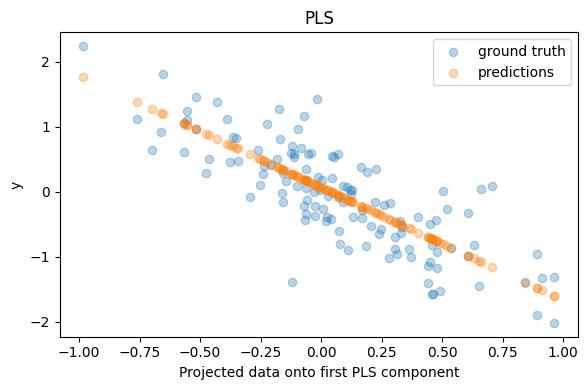

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rng)

pls = PLSRegression(n_components=1)
pls.fit(X_train, y_train)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))

axes.scatter(pls.transform(X_test), y_test, alpha=0.3, label="ground truth")
axes.scatter(
    pls.transform(X_test), pls.predict(X_test), alpha=0.3, label="predictions"
)
axes.set(xlabel="Projected data onto first PLS component", ylabel="y", title="PLS")
axes.legend()
plt.tight_layout()
plt.show()


### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

## Step: Import Modules

The goal of this step as a whole is to import all of the necessary modules needed to complete the various steps of the PLS regression pipeline.

### `PLSRegression`
Comes from the `cross_decomposition` module of scikit-learn. This import is important because it allows us to take multidimensional data and reduce it to a lower-dimensional space that maximizes the covariance of the data by taking into account both the predictor (X) class and the response (Y) class.

### `PCA`
Comes from the `decomposition` module of scikit-learn. This import is important because it allows us to take multidimensional data and reduce it to a lower-dimensional space that maximizes the variance in the predictor data. It is different from a PLS regression because it only takes into account the predictor (X) class while maximizing the variance in the data during reduction.

### `train_test_split`
Comes from the `model selection` module of scikit-learn. This function allows use to split the data array into train and test subgroups so we can train the model on a portion of the data, and then evaluate its performance on unseen data.

### `numpy`
A standalone library that allows for data array creation and efficient numerical computation. It was utilized to create a random set of x points and calculate a synthetic response class based on that data.

### `matplotlib.pyplot`
A package that allows for the creation of figures and plots. This was utilized to visualize the PLS regression in action.

In [ ]:
rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2

This block of code creates a simulated dataset and then uses PCA to create a new variable based on the second principal component. First, rng = np.random.RandomState(0) creates a random number generator with a fixed seed of 0 so the same random values will be generated each time the code runs. n_samples = 500 sets the number of observations to 500. The cov matrix describes the variance of the two variables and their covariance, meaning the two variables are positively related. Then, X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples) generates 500 observations from a two-dimensional multivariate normal distribution centered at (0, 0) using the covariance matrix. As a result, X is a 500 × 2 array containing two related variables. Next, pca = PCA(n_components=2).fit(X) performs PCA on X and calculates two principal components, which are new directions that summarize the variation in the original data. Finally, y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2 creates a new variable y by projecting each observation in X onto the second principal component and then adding random normal noise. Dividing the random noise by 2 makes the noise smaller, so y is mostly determined by the second principal component but still contains some random variation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rng)

This step splits the data into training and reporting sets. The model learns from the training data, while the reporting data allows us to evaluate its predictions on unseen observations.

In [ ]:
pls = PLSRegression(n_components=1)
pls.fit(X_train, y_train)

PLSRegression(n_components=1)

This step fits a PLS regression model with one component to the training data. It learns a weighted combination of the predictors related to the response, which it then uses to make predictions.

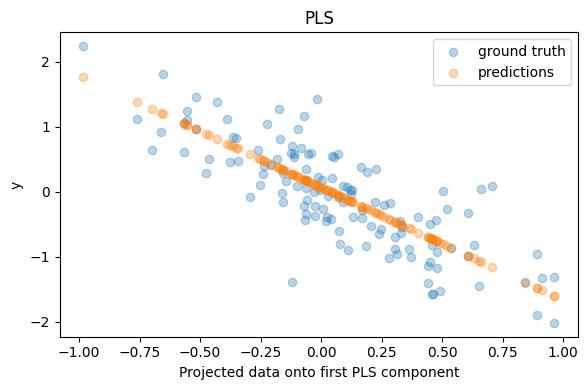

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.scatter(pls.transform(X_test), y_test, alpha=0.3, label="ground truth")
axes.scatter(
    pls.transform(X_test), pls.predict(X_test), alpha=0.3, label="predictions"
)
axes.set(xlabel="Projected data onto first PLS component", ylabel="y", title="PLS")
axes.legend()
plt.tight_layout()
plt.show()

This section creates a scatter plot comparing the actual y values with the PLS model's predicted y values. The first scatter() shows the ground truth values, while the second shows the model's predictions. pls.transform(X_test) projects the test data onto the first PLS component, which is used for the x-axis. The alpha=0.3 makes the points transparent so overlapping points are easier to see. The remaining lines add axis labels, a title, a legend, adjust the spacing, and display the plot.

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

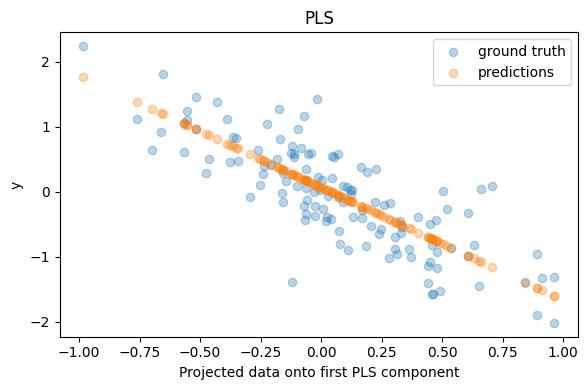

R2 Score for all Components 0.658
MSE for all compontents:  0.226


In [ ]:
# NOTE: PLEASE READ
# This is the code from Part 2(a) that I pasted down here
# so that I could reference the outputs quicker

from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rng)

pls = PLSRegression(n_components=1)
pls.fit(X_train, y_train)

# added this line to allow us to compare R2 and MSE values
y_pred = pls.predict(X_test)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))

axes.scatter(pls.transform(X_test), y_test, alpha=0.3, label="ground truth")
axes.scatter(
    pls.transform(X_test), pls.predict(X_test), alpha=0.3, label="predictions"
)
axes.set(xlabel="Projected data onto first PLS component", ylabel="y", title="PLS")
axes.legend()
plt.tight_layout()
plt.show()

# added these next lines to allow us to compare R2 and MSE values
r_2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R2 Score for all Components {r_2:.3f}')
print(f'MSE for all compontents: {mse: .3f}')

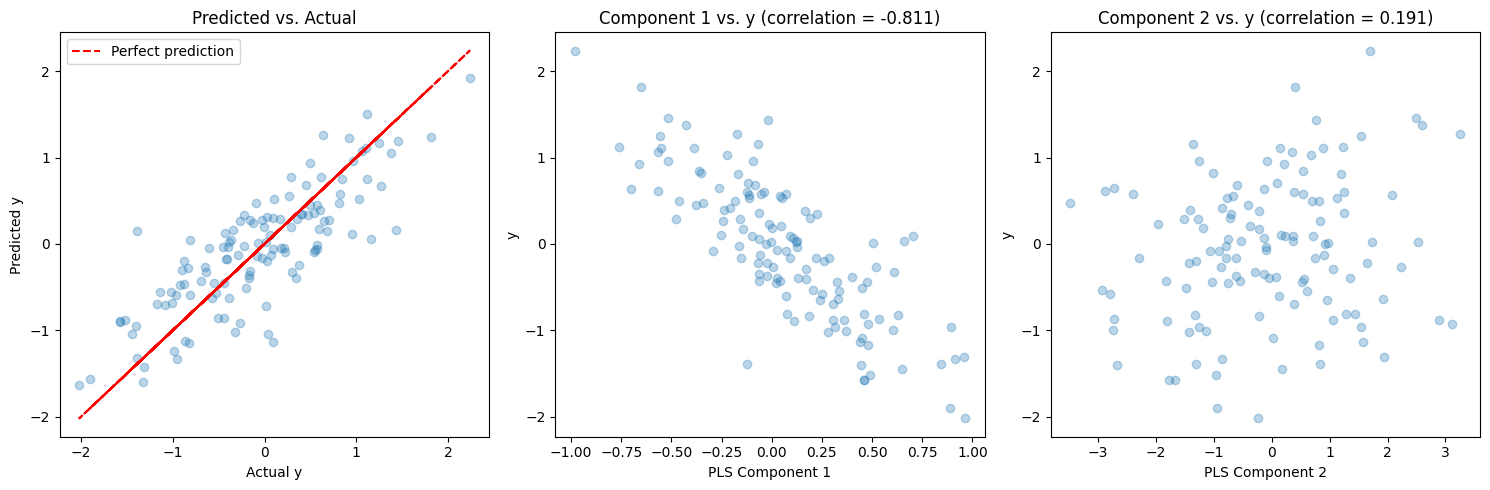

R2 Score for all Components 0.673
MSE for all compontents:  0.217


In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rng)

pls = PLSRegression(n_components=2)
pls.fit(X_train, y_train)
y_pred = pls.predict(X_test)
X_test_transformed = pls.transform(X_test)
n_components = X_test_transformed.shape[1]

fig, axes = plt.subplots(1, (n_components + 1), figsize=((5 * (n_components + 1)), 5))

axes[0].scatter(y_test, y_pred, alpha=0.3)
axes[0].plot(y_test, y_test,'r--', label="Perfect prediction")
axes[0].set(xlabel="Actual y", ylabel="Predicted y", title="Predicted vs. Actual")
axes[0].legend()

for i in range(n_components):
    component = X_test_transformed[:, i]
    corr = np.corrcoef(component, y_test)[0,1]

    ax = axes[i+1]
    ax.scatter(component, y_test, alpha = 0.3)
    ax.set(
        xlabel = f'PLS Component {1+i}',
        ylabel = 'y',
        title=f"Component {i+1} vs. y (correlation = {corr:.3f})"
    )
    r_2 = ()

plt.tight_layout()
plt.show()

r_2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R2 Score for all Components {r_2:.3f}')
print(f'MSE for all compontents: {mse: .3f}')

### d. Reflect

**What do the learned PLS components represent in your dataset?**

The learned PLS components represent the two linear combinations of X1 and X2 that explain the most covariance with y. Component 1 is the linear combination of the two features that explains the most covariance with y. Component 2 is the linear combination of the two features that explains the most covariance with y that is not already captured by Component 1.This is why it is typically orthogonal to Component 1.

**Did increasing the number of components improve performance?**

If we use R² and MSE as the metrics for determining improved performance, we do see improved performance when increasing the number of components:

| Components | R²    | MSE   |
|------------|-------|-------|
| 1          | 0.658 | 0.226 |
| 2          | 0.673 | 0.217 |

Despite both changes being relatively small, an increase in R² and a decrease in MSE both indicate increased performance. A higher R² score means a higher percentage of the variation in y is explained by the variation in the component(s), and a lower MSE means the predicted y values are, on average, closer to the actual y values with an increased number of components.

**What makes PLS different from PCA?**

The main difference between PLS and PCA is that PLS is a supervised technique that focuses on maximizing covariance between X and Y, while PCA is an unsupervised technique that focuses on maximizing the variance in X alone.

## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).

### b. Create a pipeline.

Create a pipeline that includes the following:

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.

### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.


### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²

### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.


### f. Reflect

Discuss:
- Which model performed best?
- Would you trust any of your models enough to replace the permeability lab assay?
- What would be the trade-offs of doing so?

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# a. Load and split the data
data = pd.read_csv(
    "https://raw.githubusercontent.com/UVADS/DS-4021/"
    "84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv"
)
X = data.drop(columns="permeability")
y = data["permeability"]

X_train, X_report, y_train, y_report = train_test_split(
    X, y, test_size=0.3, random_state=42
)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# b–c. Create, tune, and train the PLS pipeline
pls = GridSearchCV(
    Pipeline([
        ("variance", VarianceThreshold(0.01)),
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(scale=False))
    ]),
    {"pls__n_components": list(range(1, 21))},
    scoring="r2",
    cv=cv
)
pls.fit(X_train, y_train)

print("Predictors remaining:",
      pls.best_estimator_.named_steps["variance"].get_support().sum())
print("PLS components:", pls.best_params_["pls__n_components"])
print(f"PLS cross-validation R²: {pls.best_score_:.3f}")

# d. Evaluate on the reporting set
pls_r2 = r2_score(y_report, pls.predict(X_report).ravel())
print(f"PLS reporting R²: {pls_r2:.3f}")

# e. Tune and evaluate penalized PCR
pcr = GridSearchCV(
    Pipeline([
        ("variance", VarianceThreshold(0.01)),
        ("scaler", StandardScaler()),
        ("pca", PCA(svd_solver="full")),
        ("ridge", Ridge())
    ]),
    {
        "pca__n_components": [2, 5, 10, 15, 20, 30, 50],
        "ridge__alpha": [0.01, 0.1, 1, 10, 100]
    },
    scoring="r2",
    cv=cv
)
pcr.fit(X_train, y_train)

pcr_r2 = r2_score(y_report, pcr.predict(X_report))
print("PCR best settings:", pcr.best_params_)
print(f"PCR cross-validation R²: {pcr.best_score_:.3f}")
print(f"PCR reporting R²: {pcr_r2:.3f}")

Predictors remaining: 632
PLS components: 3
PLS cross-validation R²: 0.330
PLS reporting R²: 0.408
PCR best settings: {'pca__n_components': 50, 'ridge__alpha': 100}
PCR cross-validation R²: 0.350
PCR reporting R²: 0.442



# f. Reflection

The PLS model retained 632 predictors, and it selected a total of 3 components. Its cross-validation R² was 0.330, and its reporting R² was 0.408. This means that it explained about 41% of the variation in permeability on the reporting set. Penalized PCR performed slightly better with a reporting R² of 0.442 vs 0.408 for PLS. Its cross-validation R² was also higher, with 0.350 vs 0.330.

We should not trust either model to replace the permeability lab assay because a lot of variation remains unexplained. The model would also need additional testing on additional compounds to see how well it generalizes.

That said, the model could make screening faster and less expensive. However, if the predictions are inaccurate, this could cause the promising compounds to be discarded and unpromising compounds to be chosen. This model should be used to support lab testing rather than replace it.

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

One challenge we encountered was dividing up the workload because we spent the majority of our one class session reading and trying to understand the textbook material. For example, we found it difficult to differentiate between PLS and penalized regression based only on the textbook, which took up a significant amount of our time. This left us with less time to work through the remaining sections and divide up the questions. For future labs, we will decide from the beginning when we can meet outside of class and create a timeline for completing each part. This will help us manage our time more effectively and make sure the workload is divided evenly.
